In [829]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing
from joblib import dump
import math
from scipy.io import loadmat

import matplotlib.pyplot as plt


In [849]:
#read a matlab struct from a mat file and save it into a pd dataframe

mat = scipy.io.loadmat('../input/microstructures_object_array_final.mat')
raw_rows = mat['final_microstructure_array'][0]

column_names = raw_rows[0].dtype.names

data = []

for raw_row in raw_rows:
    row=[]
    for array in raw_row:
        if len(array[0]) == 1:
            row.append(array[0][0])
        else:
            row.append(array[0])

    data.append(row)

data

df =  pd.DataFrame(data, columns= column_names )


num_rows = df.shape[0]

# Separate the last 5 rows into a validation set
validation_df = df.iloc[num_rows - 5:]

# The rest of the rows go into the training set
training_df = df.iloc[:num_rows - 5]

df = training_df

training_df

,lath_thickness,f_alpha,f_beta,f_mart,folder,yield_stress_ZZ,Ez,yield_stress_hardening_ZZ,plastic_strain_ZZ,Pxz,yield_stress_XX,Ex,Pzx,Pyx,yield_stress_XY,Gxy,yield_stress_XZ,Gxz
0,0.2,0.0,0.0,1.0,./temp_1,1075.780357,104876.988652,"[1075.7803565876836, 1145.9313515116537, 1175....","[0.0, 0.0012362045474171319, 0.002470892591562...",0.337946,1096.398013,113746.813355,0.366422,0.235833,538.429087,45355.215256,492.640907,38458.983058
1,0.7,0.0,0.0,1.0,./temp_2,1045.577791,105080.614626,"[1070.1662170373772, 1137.7221021714643, 1168....","[0.0, 0.0012361657317530236, 0.002470780243306...",0.325972,1078.073106,115565.175346,0.358354,0.237089,538.552480,45365.489471,496.562973,38765.156974
2,1.2,0.0,0.0,1.0,./temp_3,1043.190358,104840.522195,"[1066.8710721813754, 1129.192849463698, 1155.3...","[0.0, 0.001236187804258864, 0.0024708508710111...",0.353539,1080.917950,112140.383710,0.378660,0.231810,526.086048,45509.608061,495.903442,37794.932828
3,1.7,0.0,0.0,1.0,./temp_4,1046.671411,105190.085692,"[1070.9827934452678, 1135.49681265168, 1161.48...","[0.0, 0.0012361986674078156, 0.002470862857042...",0.331488,1102.578321,114387.873598,0.361696,0.237256,526.825414,45573.470584,493.946585,38560.860332
4,2.2,0.0,0.0,1.0,./temp_5,1008.385741,108094.561901,"[1008.3857411128072, 1083.8322930848158, 1119....","[0.0, 0.0012372857749160387, 0.002473030775190...",0.316686,1052.098235,109150.890066,0.319350,0.305397,539.544341,41120.887681,538.812502,41064.892317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.7,1.0,0.0,0.0,./temp_86,857.049569,119693.059199,"[884.4046848061595, 948.9426819371743, 973.447...","[0.0, 0.0012399333856912814, 0.002478323141849...",0.320794,863.197756,120552.302203,0.322295,0.310545,453.494849,45350.189970,449.022233,44902.691337
86,1.2,1.0,0.0,0.0,./temp_87,816.259778,119169.664264,"[816.2597784851649, 892.6827400572303, 919.094...","[0.0, 0.001240350337751472, 0.0024791558658609...",0.319500,822.784076,120122.750652,0.321228,0.310144,436.952658,45114.443314,432.925554,44698.442231
87,1.7,1.0,0.0,0.0,./temp_88,781.674283,119527.061877,"[808.6922607857555, 873.4084891722856, 895.148...","[0.0, 0.0012403485093980277, 0.002479151686188...",0.319845,787.649554,120441.272038,0.321676,0.309731,423.204837,45155.241871,419.081986,44715.123738
88,2.2,1.0,0.0,0.0,./temp_89,778.246514,119002.887831,"[778.2465142900924, 851.956080861374, 876.6409...","[0.0, 0.0012408356378946547, 0.002480125279811...",0.319744,784.354650,119937.451235,0.321401,0.310097,410.372722,45292.393118,406.601897,44876.006729


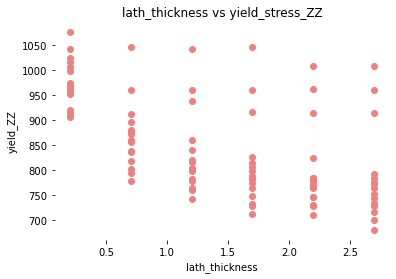

In [831]:
plt.scatter(df['lath_thickness'], df['yield_stress_ZZ'], color = 'lightcoral')
plt.title('lath_thickness vs yield_stress_ZZ')
plt.xlabel('lath_thickness')
plt.ylabel('yield_ZZ')
plt.box(False)
plt.show()



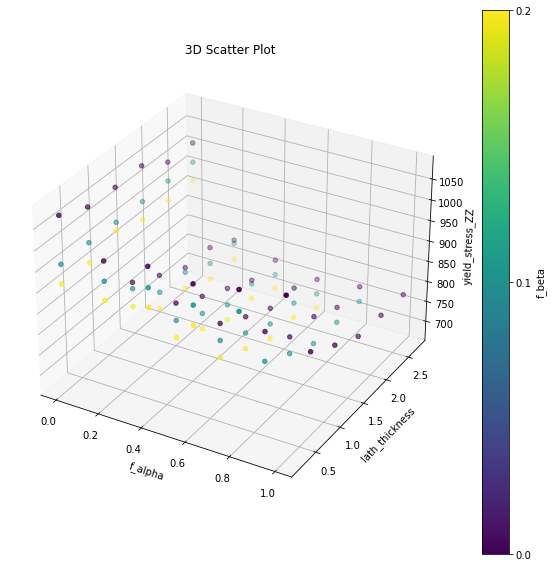

In [853]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the data
sc = ax.scatter(df['f_alpha'], df['lath_thickness'], df['yield_stress_ZZ'], c=df['f_beta'])

# Set labels and title
ax.set_xlabel('f_alpha')
ax.set_ylabel('lath_thickness')
ax.set_zlabel('yield_stress_ZZ')
ax.set_title('3D Scatter Plot')

# Add a colorbar
cbar = fig.colorbar(sc, label='f_beta')
cbar.set_ticks([0.0, 0.1, 0.2])  # Set colorbar ticks to 0.0, 0.1, and 0.2


# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/plot.jpeg')



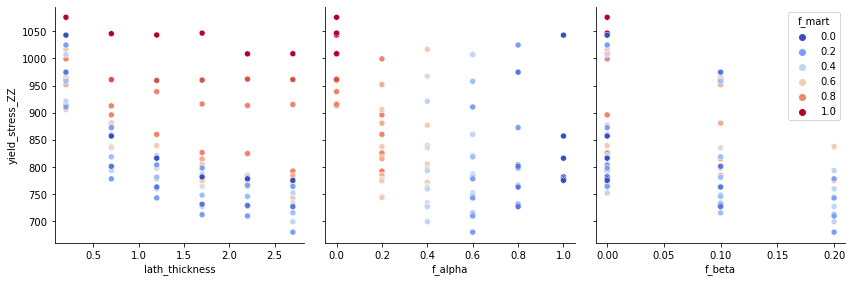

In [833]:
import seaborn as sns

# Create a PairGrid
g = sns.PairGrid(df, y_vars=['yield_stress_ZZ'], x_vars=['lath_thickness', 'f_alpha', 'f_beta'], height=4)

# Map a scatter plot to the upper triangle, color points by 'f_beta'
g.map(sns.scatterplot, hue=df['f_mart'], palette='coolwarm')

# Add a legend
plt.legend(title='f_mart')

# Show the plot
plt.show()

In [838]:
# Polynomial multi-variate regression

# Select appropriate features from the dataset
X = df[['lath_thickness','f_alpha','f_beta']].values

properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

property = 'yield_stress_XX'
y = df[property].values

# Polynomial features
poly = PolynomialFeatures(degree=6)
X_poly = poly.fit_transform(X)

# Linear Regression model
model = LinearRegression()
model.fit(X_poly, y)

r_sq = model.score(X_poly,y)
print(f"coefficient of determination: {r_sq}")

print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")


# Calculate error with validation data set:

error = []

for index, row in validation_df.iterrows():
    
    print(row['f_alpha'] + row['f_beta'])
    
    new_data = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1)  # Example values
    new_data_poly = poly.transform(new_data)


    # Predicting the price
    predicted_y = model.predict(new_data_poly)

    error.append( (predicted_y[0] - row[property]) / row[property] * 100)

print('error_percentage',error)


coefficient of determination: 0.9938659707856657
intercept: 4679163074775.803
slope: [-4.67916307e+12  9.65799742e+01  2.70184764e+02 -8.89670511e+02
 -1.70240969e+02 -3.24253831e+03  2.16550389e+02 -1.13200962e+03
  4.27861831e+03  1.18552567e+03 -3.58442341e+01  2.32895935e+03
 -2.79354559e+02  7.42182417e+03  4.42181459e+02  1.11083600e+03
  1.90626851e+03 -8.02038204e+03 -1.24062988e+04  3.73451114e+02
  1.88407112e+02 -1.48596019e+03  1.83173875e+02 -1.15963817e+03
  1.99762719e+03 -4.17753652e+01 -1.18518995e+04 -1.15732765e+04
 -4.33314260e+03  3.28919793e+02 -2.17520398e+02  4.42786094e+03
  3.33823981e+04 -3.80746201e+03  8.83248206e+01 -1.04199011e+02
  5.80606168e+02 -5.42525871e+01 -2.89912770e+02 -1.28125010e+03
 -3.63485090e+02  1.85885895e+03  3.21052603e+03  1.38870348e+03
 -6.94551943e+00  8.64524342e+03  1.33646850e+04  3.02132192e+03
 -1.30878641e+03  7.64592180e+01 -1.32877983e+03  4.06163469e+03
 -1.53593377e+04  1.01751271e+04 -8.94112626e+02  1.90284239e+01
  1.6

In [823]:
## Create Regression model for all independent variables and save them:

# Select appropriate features from the dataset
X = df[['lath_thickness','f_alpha','f_beta']].values


properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

for property in properties:
    y = df[property].values

    # Polynomial features
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    # Linear Regression model
    model = LinearRegression()
    model.fit(X_poly, y)

    dump(model, f'../data/models_saved/{property}_model.joblib')
    dump(poly, f'../data/models_saved/{property}_poly_transformer.joblib')


In [824]:
hardening = df['yield_stress_hardening_ZZ'].values

for i in range(0,len(hardening[0])):
    # values = [sub_arr[0] for sub_arr in hardening]
    stress_values_this_plastic = [sub_arr[i] for sub_arr in hardening]
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    # Linear Regression model
    model = LinearRegression()
    model.fit(X_poly, stress_values_this_plastic)

    dump(model, f'../data/models_saved/hardening_{i}_model.joblib')
    dump(poly, f'../data/models_saved/hardening_{i}_poly_transformer.joblib')


plastic_strain = df['plastic_strain_ZZ'].values

plastic_strain_average_list = []

for i in range(len(plastic_strain[0])):

    plastic_values_this_strain = [sub_array[i] for sub_array in plastic_strain]
    plastic_strain_average_list.append( sum(plastic_values_this_strain) / len(plastic_values_this_strain) )

In [860]:
## Load Model and predict properties for a given microstructure

properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

pred_prop_dict = {}

for property in properties:

    # Load the model and the transformer
    model = load(f'../data/models_saved/{property}_model.joblib')
    poly = load(f'../data/models_saved/{property}_poly_transformer.joblib')

    # New data
    new_data = np.array([[2.35,0.0,0.0]])  # Example values

    # Transform the new data using the loaded transformer
    new_data_poly = poly.transform(new_data)

    # Use the loaded model to make a prediction
    predicted_y = model.predict(new_data_poly)

    pred_prop_dict[property] = predicted_y[0]


pred_prop_dict['sigma_0'] = []
for i in range(0,len(plastic_strain_average_list)):

    # Load the model and the transformer
    model = load(f'../data/models_saved/hardening_{i}_model.joblib')
    poly = load(f'../data/models_saved/{property}_poly_transformer.joblib')

    # New data
    new_data = np.array([[2.35,1.0,0.0]])  # Example values
    # Transform the new data using the loaded transformer
    new_data_poly = poly.transform(new_data)

    # Use the loaded model to make a prediction
    predicted_y = model.predict(new_data_poly)
    pred_prop_dict['sigma_0'].append(predicted_y[0])

pred_prop_dict['strain_0'] = plastic_strain_average_list

pred_prop_dict

{'yield_stress_ZZ': 955.7084820307917,
 'yield_stress_XX': 968.6548285033924,
 'yield_stress_XY': 515.3793058091062,
 'yield_stress_XZ': 518.6872503155853,
 'Ex': 109175.28108117692,
 'Ez': 108155.44198817559,
 'Gxy': 41137.01405388457,
 'Gxz': 40923.57765044451,
 'Pxz': 0.3168587845897123,
 'Pyx': 0.30556104933169315,
 'sigma_0': [692.6919427541359,
  757.3232250428362,
  769.043159002896,
  774.2860394344268,
  779.1673206204769,
  783.6777192914617,
  787.7165032530015,
  791.3203362602578,
  794.6070777072161,
  797.669636471601,
  800.5704695970035,
  803.3490507733555,
  806.0323672920288,
  808.6383464406747],
 'strain_0': [0.0,
  0.0012405158305158531,
  0.0024795196563349234,
  0.003717013384574665,
  0.004952992616195862,
  0.006187457314362066,
  0.0074204115272880206,
  0.008651859936631635,
  0.009881806557771286,
  0.011110255010765728,
  0.012337207783767602,
  0.013562670615328879,
  0.014786635860760722,
  0.016009155601485622]}

In [863]:
## Write Material info in Abaqus inp format:

#Calculate Hill Parameters from yield stresses
sigma_0 = pred_prop_dict['yield_stress_ZZ']
R11 = pred_prop_dict['yield_stress_XX']/sigma_0
R22 = R11
R33 = 1
R12 = pred_prop_dict['yield_stress_XY']/(sigma_0/math.sqrt(3))
R13 = pred_prop_dict['yield_stress_XZ']/(sigma_0/math.sqrt(3))
R23 = R13

hardening_string = ''
for i in range(len(pred_prop_dict['strain_0'])):
    hardening_string += f"{pred_prop_dict['sigma_0'][i]},{pred_prop_dict['strain_0'][i]} \n"


#Write Material info in Abaqus inp format:
Material_Abaqus_text =f'''**
*Material, name=Material-1
*Elastic, type=ENGINEERING CONSTANTS
{pred_prop_dict['Ex']},{pred_prop_dict['Ex']},{pred_prop_dict['Ez']}, {pred_prop_dict['Pyx']}, {pred_prop_dict['Pxz']}, {pred_prop_dict['Pxz']}, {pred_prop_dict['Gxz']}, {pred_prop_dict['Gxz'], {pred_prop_dict['Gxz']}},
*Plastic
 {hardening_string}
*Potential
 {R11}, {R22},  {R33},  {R12},  {R12},  {R23}
 '''


with open('../data/material.inp', 'w') as f:
    # Write the string to the file
    f.write(Material_Abaqus_text)


In [848]:
## Linear_Interpolation in 3D unstructured grid

import numpy as np
from scipy.interpolate import griddata

property = 'yield_stress_ZZ'

# Define the points where you know the function values
points = df[['lath_thickness','f_alpha','f_beta']].values # 100 points in 3D
values = df[property].values

# Define the point where you want to interpolate
interp_point = np.array([0.5, 0.0, 0.0])

# Perform the interpolation
interp_value = griddata(points, values, [interp_point], method='linear')

interp_value

# Calculate error with validation data set:

error = []

for index, row in validation_df.iterrows():

    
    interp_point = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1)  # Example values
    print(interp_point)
    interp_value = griddata(points, values, [interp_point], method='linear')


    predicted_y = interp_value[0]
    error.append( ( (predicted_y - row[property]) / row[property] ) * 100 )

print('error_percentage',error)


[[1.42 0.88 0.12]]
[[0.85 0.   0.  ]]
[[2.35 0.8  0.1 ]]
[[1.35 1.   0.  ]]
[[2.6 0.  0. ]]
error_percentage [array([nan]), array([3.59187101]), array([0.23540794]), array([2.6590808]), array([0.00324369])]


In [845]:
#RBF Interpolation

import numpy as np
from scipy.interpolate import RBFInterpolator


property = 'yield_stress_XX'

# Define the points where you know the function values
points = df[['lath_thickness','f_alpha','f_beta']].values # 100 points in 3D
values = df[property].values

# Define the point where you want to interpolate
rbf = RBFInterpolator(points, values, kernel = 'multiquadric', epsilon = 4.0)


# interp_value = rbf([[2.35, 0.8, 0.1]])

# Calculate error with validation data set:
error = []

for index, row in validation_df.iterrows():

    
    interp_point = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1) 
    interp_value = rbf( interp_point )

    predicted_y = interp_value[0]

    print(predicted_y)

    error.append( ( (predicted_y - row[property]) / row[property] ) * 100 )

print('error_percentage',error)


770.2673945644008
1075.5490028133643
750.3805559673233
811.4558983128929
1048.5282296603034
error_percentage [-2.09163278315897, 2.23557237438625, 0.03857846511699751, 2.6594057961598567, -0.3312991907214024]
